In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('darkgrid')


In [2]:
df = pd.read_csv('../data/anonymized_costs.csv')
print("Shape:", df.shape)
df.head()


Shape: (93605, 11)


,InvoiceSectionName,Date,MeterCategory,CostInBillingCurrency,MeterSubCategory,MeterName,SubscriptionName,ResourceGroup,ConsumedService,ResourceLocation,ResourceName
0,bc05844fb9454a82a5380ad11fceccc59227e495d31ab1...,12/31/2022,Azure App Service,0.000000,Free Plan,F1 App,95e7dd23f5eed773783fc94e66ed6198d77b9b7c41c51c...,8e04551db18efa5f0d61d169fc2abbc0a0fe47b337d340...,microsoft.web,westeurope,eb7b2b2291b962a3591cb5284020ee75b4c02937fed01c...
1,bc05844fb9454a82a5380ad11fceccc59227e495d31ab1...,12/31/2022,Load Balancer,0.018600,Standard,Standard Included LB Rules and Outbound Rules,95e7dd23f5eed773783fc94e66ed6198d77b9b7c41c51c...,05a92ef059d22b7847bf97a414cbd9b773f230a341f926...,Microsoft.MachineLearningServices,westeurope,55f17ee5c0235396a7acc69e7fc30d917319e3e053d08e...
2,bc05844fb9454a82a5380ad11fceccc59227e495d31ab1...,12/31/2022,Storage,0.000004,Tables,GRS Data Stored,95e7dd23f5eed773783fc94e66ed6198d77b9b7c41c51c...,334f28a0945bbab90ebf4a794cac86f5cfe3aacdc42cd2...,Microsoft.Storage,northeurope,b92f8ef6e1ac3ee7ca538e4b03926bbba53e01f1ce6088...
3,bc05844fb9454a82a5380ad11fceccc59227e495d31ab1...,12/31/2022,Load Balancer,0.018600,Standard,Standard Included LB Rules and Outbound Rules,95e7dd23f5eed773783fc94e66ed6198d77b9b7c41c51c...,05a92ef059d22b7847bf97a414cbd9b773f230a341f926...,Microsoft.MachineLearningServices,westeurope,55f17ee5c0235396a7acc69e7fc30d917319e3e053d08e...
4,bc05844fb9454a82a5380ad11fceccc59227e495d31ab1...,12/31/2022,Storage,0.014312,Standard SSD Managed Disks,E2 Disks,95e7dd23f5eed773783fc94e66ed6198d77b9b7c41c51c...,43c17db9ed1b2f8fb2b00a32c6223f6e6b1e4b9b92b5c3...,Microsoft.Compute,northeurope,c97e6c1b0d7cd5a7a56903385811b0a621aa0873089ab8...


In [3]:
df.nunique().sort_values(ascending=False)


CostInBillingCurrency    15057
ResourceName              1615
ResourceGroup              320
MeterName                  219
MeterSubCategory            92
Date                        89
MeterCategory               50
ConsumedService             37
ResourceLocation            12
InvoiceSectionName           1
SubscriptionName             1
dtype: int64

<h2 style="color:#059669;">➤ <b>Observations After Understanding the Dataset</b></h2>

# Total Columns : 11 

<b>1. ➜ <code>InvoiceSectionName</code> represents the working section for which invoice is generated, and all rows have the same <code>InvoiceSectionName</code>, so we will drop it later.</b><br><br>

<b>2. ➜ <code>Date</code> represents the billing date (keep it by converting it into features).</b><br><br>

<b>3. ➜ <code>MeterCategory</code> represents the main Azure services and has 50 unique values, so we will keep it because different categories can have different <code>CostInBillingCurrency</code>.</b><br><br>

<b>4. ➜ <code>CostInBillingCurrency</code> is our target variable (y) because we have to predict it.</b><br><br>

<b>5. ➜ <code>MeterSubCategory</code> represents a more detailed service type, has 92 unique values, and we will keep it.</b><br><br>

<b>6. ➜ <code>MeterName</code> is the exact thing Azure is charging money for, so we will keep it.</b><br><br>

<b>7. ➜ <code>SubscriptionName</code> is the same for all rows, so we will drop it.</b><br><br>

<b>8. ➜ <code>ResourceGroup</code> is a group containing related Azure resources. We will drop it because it is not a suitable feature for our project.</b><br><br>

<b>9. ➜ <code>ConsumedService</code> is the Azure service namespace, has 33 unique values, and represents which Azure service actually consumed the resources and generated the billing charge.</b><br><br>

<b>10. ➜ <code>ResourceLocation</code> represents the resource locations, and we will drop it.</b><br><br>

<b>11. ➜ <code>ResourceName</code> represents the name of the individual Azure resource, and we will drop it.</b>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93605 entries, 0 to 93604
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   InvoiceSectionName     93605 non-null  object 
 1   Date                   93605 non-null  object 
 2   MeterCategory          93605 non-null  object 
 3   CostInBillingCurrency  93605 non-null  float64
 4   MeterSubCategory       93605 non-null  object 
 5   MeterName              93605 non-null  object 
 6   SubscriptionName       93605 non-null  object 
 7   ResourceGroup          93605 non-null  object 
 8   ConsumedService        93605 non-null  object 
 9   ResourceLocation       93605 non-null  object 
 10  ResourceName           93605 non-null  object 
dtypes: float64(1), object(10)
memory usage: 7.9+ MB


In [5]:
#lets check duplicated  row

print("Duplicate rows:", df.duplicated().sum())
print()
df.isnull().sum()


Duplicate rows: 20205



InvoiceSectionName       0
Date                     0
MeterCategory            0
CostInBillingCurrency    0
MeterSubCategory         0
MeterName                0
SubscriptionName         0
ResourceGroup            0
ConsumedService          0
ResourceLocation         0
ResourceName             0
dtype: int64

In [6]:
df.nunique().sort_values(ascending=False)

CostInBillingCurrency    15057
ResourceName              1615
ResourceGroup              320
MeterName                  219
MeterSubCategory            92
Date                        89
MeterCategory               50
ConsumedService             37
ResourceLocation            12
InvoiceSectionName           1
SubscriptionName             1
dtype: int64

<h2 style="color:#059669;">➤ <b> Observations :</b></h2>

<b>➜ No missing values in any column.</b><br><br>

<b>➜ There are duplicate rows — likely repeated identical billing line entries — which will be removed during cleaning</b><br><br>

<b>➜ <code>InvoiceSectionName</code> and <code>SubscriptionName</code> have only <b>1 unique value</b> each → they carry zero predictive signal and will be dropped</b><br><br>

<b>➜ <code>ResourceGroup</code> (320 unique) and <code>ResourceName</code> (1,615 unique) are effectively unique identifiers with no generalizable pattern → will be dropped</b><br><br>

<b>➜ <code>MeterCategory</code>, <code>MeterSubCategory</code>, <code>MeterName</code>, <code>ConsumedService</code>, <code>ResourceLocation</code> are genuine categorical <i>features</i> that describe the service being billed and will be kept</b>

<mark><b>Exploratory Data Analysis (EDA)

In [7]:
df['CostInBillingCurrency'].describe()

count    93605.000000
mean         0.101932
std          0.465012
min          0.000000
25%          0.000002
50%          0.001696
75%          0.028190
max         26.902857
Name: CostInBillingCurrency, dtype: float64

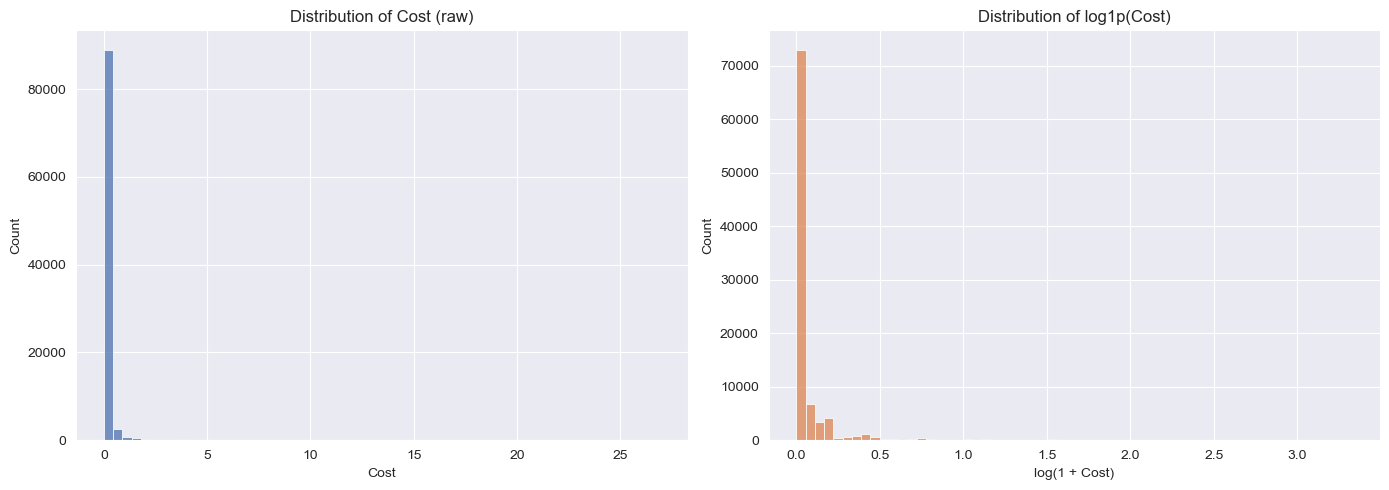

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['CostInBillingCurrency'], bins=60, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Cost (raw)')
axes[0].set_xlabel('Cost')

sns.histplot(np.log1p(df['CostInBillingCurrency']), bins=60, ax=axes[1], color='#DD8452')
axes[1].set_title('Distribution of log1p(Cost)')
axes[1].set_xlabel('log(1 + Cost)')

plt.tight_layout()
plt.savefig('../images/01_cost_distribution.png', dpi=100)
plt.show()


<b>➜ The raw cost distribution is heavily right-skewed indicating that most billing line items have very low costs, while a small number of resources generate significantly higher charges. This pattern is typical of cloud usage data where numerous small metering events coexist with a few expensive resource consumption events</b>

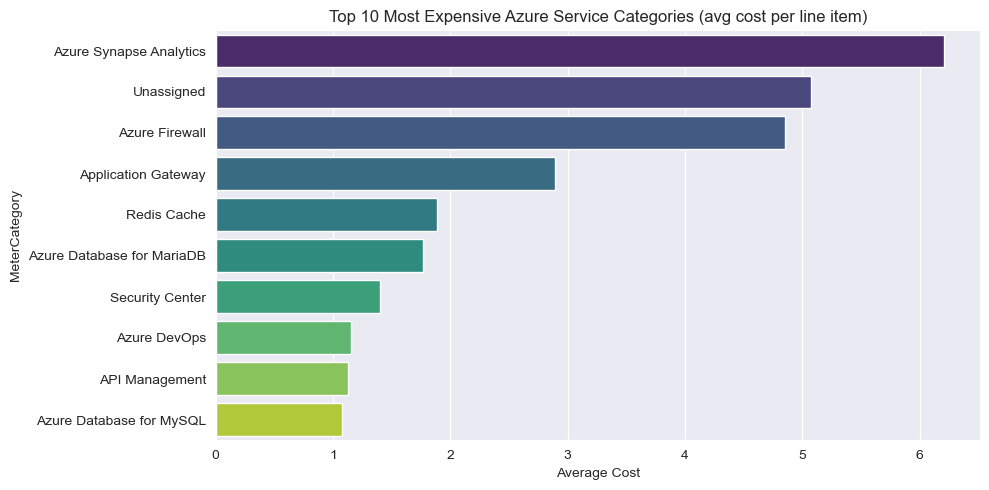

In [9]:
top_expensive = df.groupby('MeterCategory')['CostInBillingCurrency'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_expensive.values, y=top_expensive.index, palette='viridis')
plt.title('Top 10 Most Expensive Azure Service Categories (avg cost per line item)')
plt.xlabel('Average Cost')
plt.tight_layout()
plt.savefig('../images/02_top_expensive_categories.png', dpi=100)
plt.show()


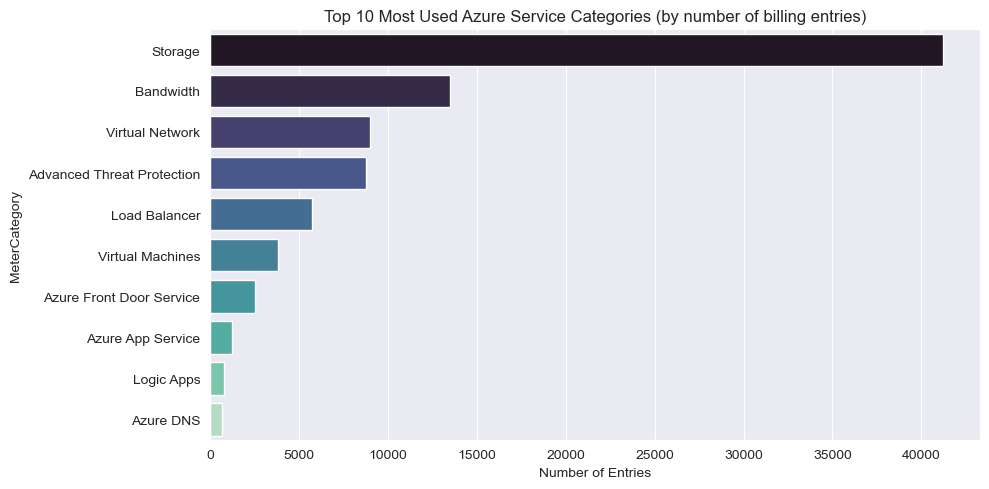

In [10]:
most_used = df['MeterCategory'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=most_used.values, y=most_used.index, palette='mako')
plt.title('Top 10 Most Used Azure Service Categories (by number of billing entries)')
plt.xlabel('Number of Entries')
plt.tight_layout()
plt.savefig('../images/03_most_used_categories.png', dpi=100)
plt.show()


In [11]:
region_cost = df.assign(ResourceLocation=df['ResourceLocation'].str.lower()).groupby('ResourceLocation')['CostInBillingCurrency'].sum().sort_values(ascending=False)


region_cost

ResourceLocation
westeurope        6447.104560
unassigned        1434.324680
northeurope        980.906017
southeastasia      433.659339
eastus              91.899369
westus              74.696012
all regions         70.963614
europewest           7.830000
eastus2              0.000040
westus2              0.000035
northcentralus       0.000013
europe               0.000000
Name: CostInBillingCurrency, dtype: float64

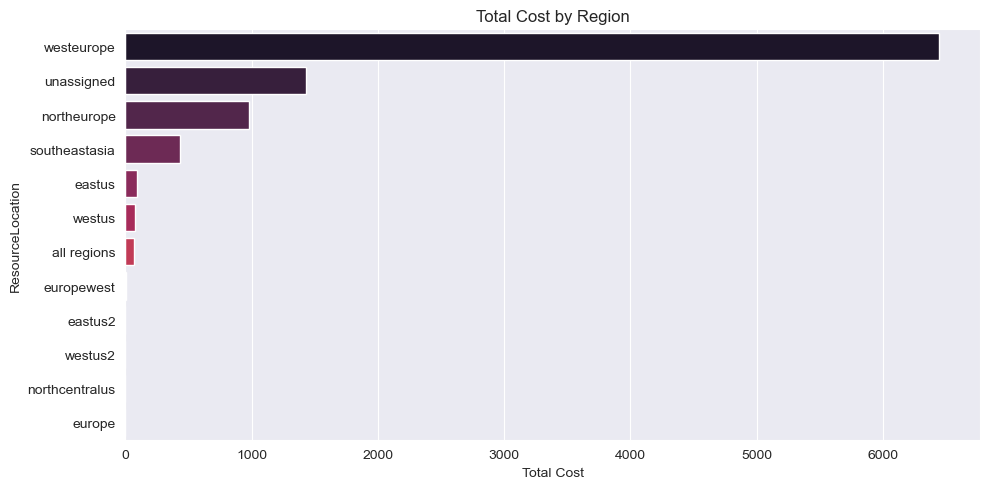

In [12]:
# Normalize casing before this analysis so 'westeurope' and 'WestEurope' aren't counted separately


region_cost = df.assign(ResourceLocation=df['ResourceLocation'].str.lower()).groupby('ResourceLocation')['CostInBillingCurrency'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=region_cost.values, y=region_cost.index, palette='rocket')
plt.title('Total Cost by Region')
plt.xlabel('Total Cost')
plt.tight_layout()
plt.savefig('../images/04_cost_by_region.png', dpi=100)
plt.show()


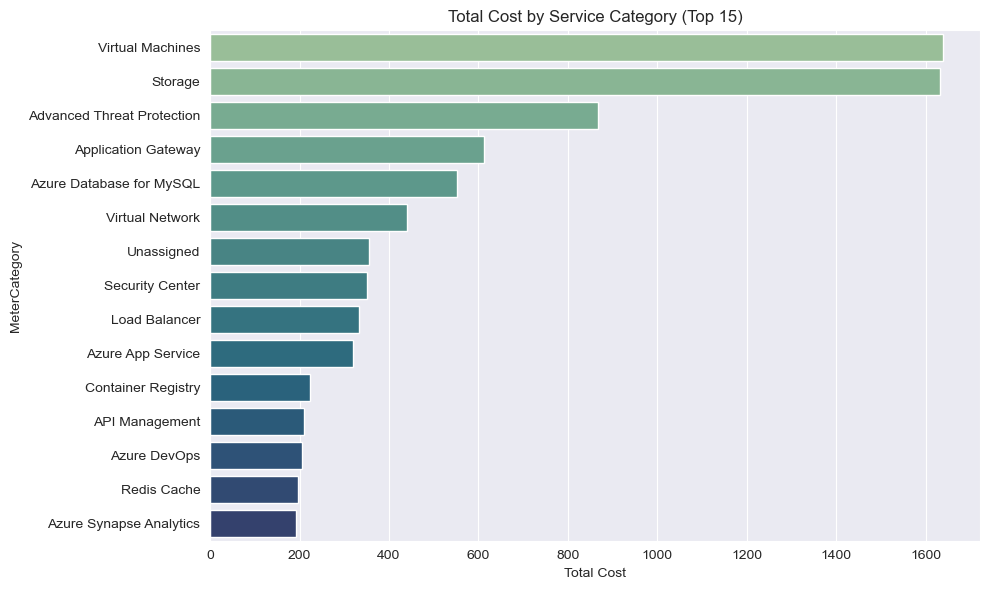

In [13]:
category_cost = df.groupby('MeterCategory')['CostInBillingCurrency'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=category_cost.values, y=category_cost.index, palette='crest')
plt.title('Total Cost by Service Category (Top 15)')
plt.xlabel('Total Cost')
plt.tight_layout()
plt.savefig('../images/05_total_cost_by_category.png', dpi=100)
plt.show()


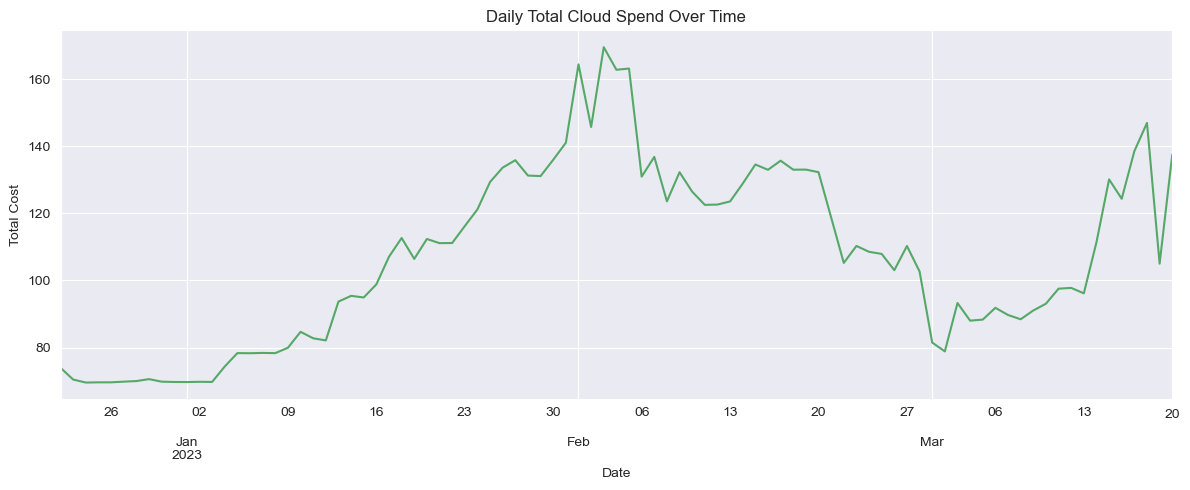

In [14]:
df['Date_parsed'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
monthly = df.set_index('Date_parsed').resample('D')['CostInBillingCurrency'].sum()

plt.figure(figsize=(12, 5))
monthly.plot(color='#55A868')
plt.title('Daily Total Cloud Spend Over Time')
plt.ylabel('Total Cost')
plt.xlabel('Date')
plt.tight_layout()
plt.savefig('../images/06_daily_spend_trend.png', dpi=100)
plt.show()


In [15]:
df.head()

,InvoiceSectionName,Date,MeterCategory,CostInBillingCurrency,MeterSubCategory,MeterName,SubscriptionName,ResourceGroup,ConsumedService,ResourceLocation,ResourceName,Date_parsed
0,bc05844fb9454a82a5380ad11fceccc59227e495d31ab1...,12/31/2022,Azure App Service,0.000000,Free Plan,F1 App,95e7dd23f5eed773783fc94e66ed6198d77b9b7c41c51c...,8e04551db18efa5f0d61d169fc2abbc0a0fe47b337d340...,microsoft.web,westeurope,eb7b2b2291b962a3591cb5284020ee75b4c02937fed01c...,2022-12-31
1,bc05844fb9454a82a5380ad11fceccc59227e495d31ab1...,12/31/2022,Load Balancer,0.018600,Standard,Standard Included LB Rules and Outbound Rules,95e7dd23f5eed773783fc94e66ed6198d77b9b7c41c51c...,05a92ef059d22b7847bf97a414cbd9b773f230a341f926...,Microsoft.MachineLearningServices,westeurope,55f17ee5c0235396a7acc69e7fc30d917319e3e053d08e...,2022-12-31
2,bc05844fb9454a82a5380ad11fceccc59227e495d31ab1...,12/31/2022,Storage,0.000004,Tables,GRS Data Stored,95e7dd23f5eed773783fc94e66ed6198d77b9b7c41c51c...,334f28a0945bbab90ebf4a794cac86f5cfe3aacdc42cd2...,Microsoft.Storage,northeurope,b92f8ef6e1ac3ee7ca538e4b03926bbba53e01f1ce6088...,2022-12-31
3,bc05844fb9454a82a5380ad11fceccc59227e495d31ab1...,12/31/2022,Load Balancer,0.018600,Standard,Standard Included LB Rules and Outbound Rules,95e7dd23f5eed773783fc94e66ed6198d77b9b7c41c51c...,05a92ef059d22b7847bf97a414cbd9b773f230a341f926...,Microsoft.MachineLearningServices,westeurope,55f17ee5c0235396a7acc69e7fc30d917319e3e053d08e...,2022-12-31
4,bc05844fb9454a82a5380ad11fceccc59227e495d31ab1...,12/31/2022,Storage,0.014312,Standard SSD Managed Disks,E2 Disks,95e7dd23f5eed773783fc94e66ed6198d77b9b7c41c51c...,43c17db9ed1b2f8fb2b00a32c6223f6e6b1e4b9b92b5c3...,Microsoft.Compute,northeurope,c97e6c1b0d7cd5a7a56903385811b0a621aa0873089ab8...,2022-12-31


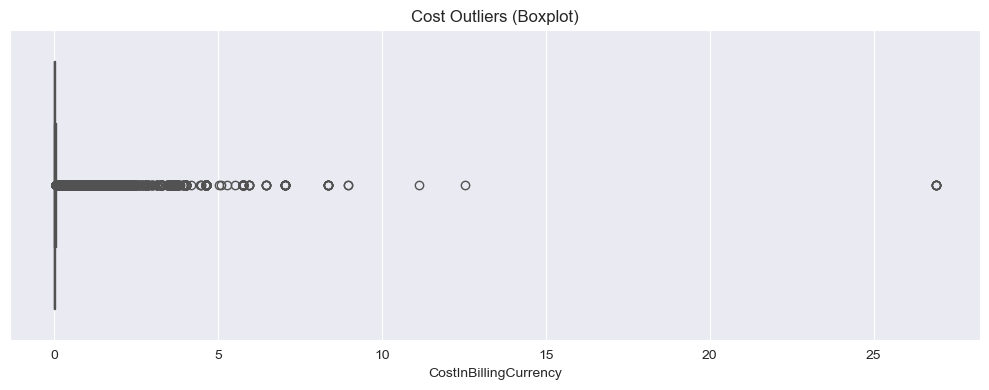

Upper fence (IQR method): 0.0705
Rows above upper fence: 17682 (18.89%)


In [16]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['CostInBillingCurrency'], color='#C44E52')
plt.title('Cost Outliers (Boxplot)')
plt.tight_layout()
plt.savefig('../images/07_cost_outliers.png', dpi=100)
plt.show()

q1, q3 = df['CostInBillingCurrency'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
print(f"Upper fence (IQR method): {upper_fence:.4f}")
print(f"Rows above upper fence: {(df['CostInBillingCurrency'] > upper_fence).sum()} ({(df['CostInBillingCurrency'] > upper_fence).mean()*100:.2f}%)")


<b>➜ Although the IQR method identifies many statistical outliers, these represent legitimate high-cost billing events (such as large Virtual Machines, AI/ML training workloads, or other resource-intensive services) rather than data errors. Since predicting these expensive usage patterns is one of the primary objectives of this project, the outliers will be retained instead of removed</b>

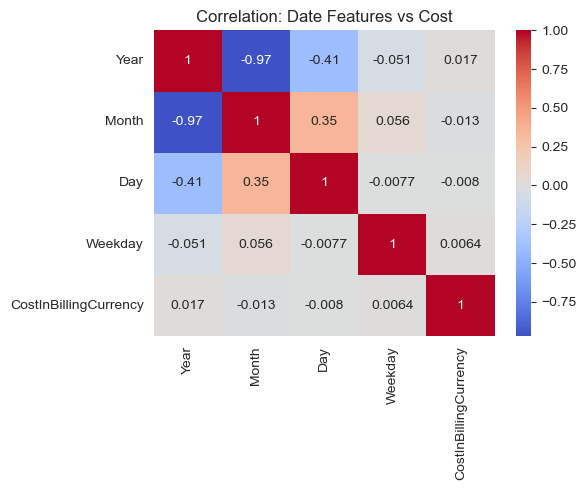

In [17]:
# Correlation among engineered numeric/date features (categorical correlation isn't meaningful pre-encoding)

df['Year'] = df['Date_parsed'].dt.year
df['Month'] = df['Date_parsed'].dt.month
df['Day'] = df['Date_parsed'].dt.day
df['Weekday'] = df['Date_parsed'].dt.weekday

corr = df[['Year', 'Month', 'Day', 'Weekday', 'CostInBillingCurrency']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Date Features vs Cost')
plt.tight_layout()
plt.savefig('../images/08_correlation_heatmap.png', dpi=100)
plt.show()


<b>➜ Date-derived features show a weak linear correlation with <code>CostInBillingCurrency</code> individually, indicating that cloud cost is influenced far more by the type of Azure service being billed than by the billing date. Therefore, the categorical service-related features are expected to carry most of the predictive power</b>

<b><mark>Data Cleaning

In [18]:
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - df.shape[0]} duplicate rows -> new shape: {df.shape}")


Dropped 20205 duplicate rows -> new shape: (73400, 16)


In [19]:
# Fix inconsistent casing found during EDA (e.g. 'Microsoft.Storage' vs 'microsoft.storage', 'WestEurope' vs 'westeurope')

for col in ['ConsumedService', 'ResourceLocation', 'MeterCategory', 'MeterSubCategory', 'MeterName']:
    df[col] = df[col].astype(str).str.strip().str.lower()

print("Unique ConsumedService values after cleaning:", df['ConsumedService'].nunique())
print("Unique ResourceLocation values after cleaning:", df['ResourceLocation'].nunique())


Unique ConsumedService values after cleaning: 33
Unique ResourceLocation values after cleaning: 12


In [20]:
# Date already parsed as Date_parsed above; confirm dtype and no bad parses

print(df['Date_parsed'].dtype)
print("Any NaT after parsing:", df['Date_parsed'].isna().sum())


datetime64[ns]
Any NaT after parsing: 0


<mark><b>Feature Engineering

`Year`, `Month`, `Day`, `Weekday` were already derived from `Date` above (needed for the correlation check). We keep them and drop the raw `Date` / `Date_parsed` columns.

In [21]:
df = df.drop(columns=['Date', 'Date_parsed'])
df[['Year', 'Month', 'Day', 'Weekday']].describe()


,Year,Month,Day,Weekday
count,73400.000000,73400.000000,73400.000000,73400.000000
mean,2022.913120,2.750531,15.635940,2.958202
std,0.281661,2.944615,8.551003,1.988625
min,2022.000000,1.000000,1.000000,0.000000
25%,2023.000000,1.000000,8.000000,1.000000
50%,2023.000000,2.000000,16.000000,3.000000
75%,2023.000000,3.000000,23.000000,5.000000
max,2023.000000,12.000000,31.000000,6.000000


<b><mark>Feature Selection and Encoding

**Dropped (pure identifiers / zero-variance / not learnable patterns):**
- `InvoiceSectionName` — constant (1 unique value)
- `SubscriptionName` — constant (1 unique value)
- `ResourceGroup` — 320 unique values, effectively an ID
- `ResourceName` — 1,615 unique values, effectively an ID

**One-Hot Encoded** (low cardinality, meaningful categories the model can generalize across):
- `MeterCategory`, `ConsumedService`, `ResourceLocation`

**Ordinal / Label Encoded** (higher cardinality — one-hot would create hundreds of sparse columns):
- `MeterSubCategory`, `MeterName`

No `ColumnTransformer` / `Pipeline` is used here. Instead, the `StandardScaler`, `OneHotEncoder`, and `OrdinalEncoder` are created and fit manually, and their fitted objects are saved individually. This means the Streamlit app has to load each encoder separately and apply them in the exact same order used here — a bit more manual bookkeeping, but it keeps every transformation step visible and explicit.


In [22]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

id_cols = ['InvoiceSectionName', 'SubscriptionName', 'ResourceGroup', 'ResourceName']
df_model = df.drop(columns=id_cols)

target = 'CostInBillingCurrency'
numeric_features = ['Year', 'Month', 'Day', 'Weekday']
onehot_features = ['MeterCategory', 'ConsumedService', 'ResourceLocation']
ordinal_features = ['MeterSubCategory', 'MeterName']

X = df_model.drop(columns=[target])
y = df_model[target]

X.head()


,MeterCategory,MeterSubCategory,MeterName,ConsumedService,ResourceLocation,Year,Month,Day,Weekday
0,azure app service,free plan,f1 app,microsoft.web,westeurope,2022,12,31,5
1,load balancer,standard,standard included lb rules and outbound rules,microsoft.machinelearningservices,westeurope,2022,12,31,5
2,storage,tables,grs data stored,microsoft.storage,northeurope,2022,12,31,5
3,storage,standard ssd managed disks,e2 disks,microsoft.compute,northeurope,2022,12,31,5
4,storage,standard ssd managed disks,e2 disks,microsoft.compute,northeurope,2022,12,30,4


<b><mark>Train-Test Split Now 

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (58720, 9)
Test shape: (14680, 9)


<mark>Feature Scaling & Encoding 

`StandardScaler` is applied to the numeric date features. `OneHotEncoder` and `OrdinalEncoder` handle the categorical columns. Each is fit **only on the training data** to avoid data leakage, then used to transform both the train and test sets. The three transformed pieces are then stacked together with `np.hstack` in a fixed, documented column order (`numeric_features + onehot_features + ordinal_features`) so the same order can be reproduced later in the Streamlit app


In [24]:
scaler = StandardScaler()
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

scaler.fit(X_train[numeric_features])
onehot_encoder.fit(X_train[onehot_features])
ordinal_encoder.fit(X_train[ordinal_features])

X_train_num = scaler.transform(X_train[numeric_features])
X_train_oh = onehot_encoder.transform(X_train[onehot_features])
X_train_ord = ordinal_encoder.transform(X_train[ordinal_features])

X_test_num = scaler.transform(X_test[numeric_features])
X_test_oh = onehot_encoder.transform(X_test[onehot_features])
X_test_ord = ordinal_encoder.transform(X_test[ordinal_features])

X_train_processed = np.hstack([X_train_num, X_train_oh, X_train_ord])
X_test_processed = np.hstack([X_test_num, X_test_oh, X_test_ord])

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)


X_train_processed shape: (58720, 101)
X_test_processed shape: (14680, 101)


<mark><b>Model Training — Linear Regression

In [25]:
model = LinearRegression()
model.fit(X_train_processed, y_train)
print("Model trained.")


Model trained.


## Prediction

In [26]:
y_pred = model.predict(X_test_processed)
y_pred[:10]


array([ 0.1138044 , -0.03386019, -0.03195277,  0.14827557,  0.11833961,
        0.25060234, -0.02155962,  0.04009502,  0.02524787,  0.11296766])

<b><mark> Model Evaluation

In [27]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.6f}")
print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R2   : {r2:.6f}")


MAE  : 0.105645
MSE  : 0.094141
RMSE : 0.306824
R2   : 0.458884


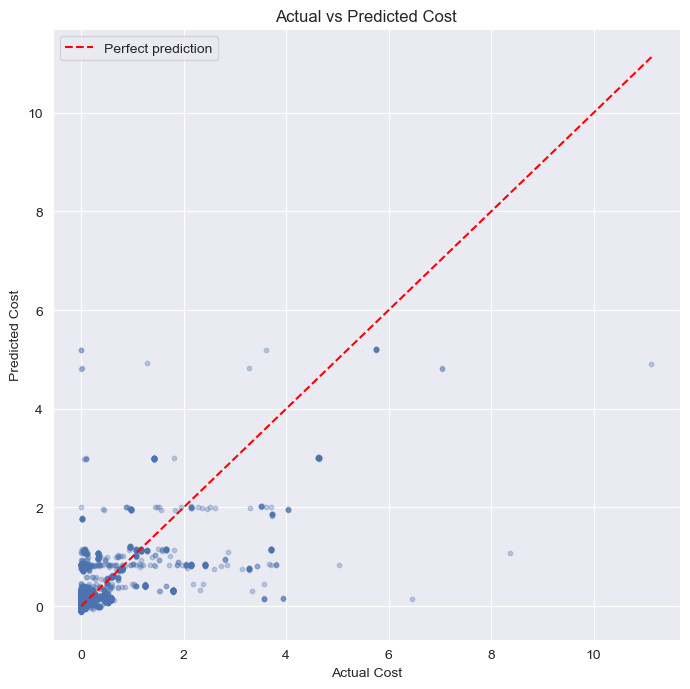

In [30]:
# actual vs predicted values

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, s=10, color='#4C72B0')
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual Cost')
plt.ylabel('Predicted Cost')
plt.title('Actual vs Predicted Cost')
plt.legend()
plt.tight_layout()
plt.savefig('../images/09_actual_vs_predicted.png', dpi=100)
plt.show()


In [29]:
#lets save model 


with open('../models/linear_regression_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../models/onehot_encoder.pkl', 'wb') as f:
    pickle.dump(onehot_encoder, f)

with open('../models/ordinal_encoder.pkl', 'wb') as f:
    pickle.dump(ordinal_encoder, f)

feature_schema = {
    'numeric_features': numeric_features,
    'onehot_features': onehot_features,
    'ordinal_features': ordinal_features,
    'all_features_in_order': numeric_features + onehot_features + ordinal_features,
}
with open('../models/feature_schema.pkl', 'wb') as f:
    pickle.dump(feature_schema, f)

category_options = {col: sorted(df_model[col].dropna().unique().tolist()) for col in onehot_features + ordinal_features}
with open('../models/category_options.pkl', 'wb') as f:
    pickle.dump(category_options, f)



Saved: linear_regression_model.pkl, scaler.pkl, onehot_encoder.pkl, ordinal_encoder.pkl, feature_schema.pkl, category_options.pkl


### completed</b>